In [1]:
# ===============================
# 1️. Define Problem Statement
# ===============================
# Goal: Predict a personalized healthy diet and yoga recommendation
# based on user lifestyle, exercise habits, health conditions, and preferences.

In [2]:
# ===============================
# 2️ Collect Data
# ===============================
import pandas as pd
import numpy as np

# Load the final updated CSV
df = pd.read_csv('final_data_updated.csv')

print("Dataset Loaded:")
print(df.head())

Dataset Loaded:
     Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0  34.91    Male        65.27        1.62   188.58   157.65        69.05   
1  23.37  Female        56.41        1.55   179.43   131.75        73.18   
2  33.20  Female        58.98        1.67   175.04   123.95        54.96   
3  38.69  Female        93.78        1.70   191.21   155.10        50.07   
4  45.09    Male        52.42        1.88   193.58   152.88        70.84   

   Session_Duration (hours)  Calories_Burned Workout_Type  ...  cal_balance  \
0                      1.00          1080.90     Strength  ...       725.10   
1                      1.37          1809.91         HIIT  ...      -232.91   
2                      0.91           802.26       Cardio  ...       805.74   
3                      1.10          1450.79         HIIT  ...      1206.21   
4                      1.08          1166.40     Strength  ...       303.60   

   lean_mass_kg  expected_burn  Burns Calories (per 

In [3]:
for col in df.columns:
    print(col)

Age
Gender
Weight (kg)
Height (m)
Max_BPM
Avg_BPM
Resting_BPM
Session_Duration (hours)
Calories_Burned
Workout_Type
Fat_Percentage
Water_Intake (liters)
Workout_Frequency (days/week)
Experience_Level
BMI
Daily meals frequency
Physical exercise
Carbs
Proteins
Fats
Calories
meal_name
meal_type
diet_type
sugar_g
sodium_mg
cholesterol_mg
serving_size_g
cooking_method
prep_time_min
cook_time_min
rating
Name of Exercise
Sets
Reps
Benefit
Burns Calories (per 30 min)
Target Muscle Group
Equipment Needed
Difficulty Level
Body Part
Type of Muscle
Workout
BMI_calc
cal_from_macros
pct_carbs
protein_per_kg
pct_HRR
pct_maxHR
cal_balance
lean_mass_kg
expected_burn
Burns Calories (per 30 min)_bc
Burns_Calories_Bin
Sleep_Hours
Water_Intake
Diet_Preference
Stress_Level
Health_Condition


In [4]:
# ===============================
# 3️⃣ Data Preparation (warning fixed)
# ===============================
import pandas as pd
import numpy as np

# Select input features
X = df[['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Physical exercise', 
        'diet_type', 'Experience_Level', 'Sleep_Hours', 'Water_Intake', 
        'Diet_Preference', 'Stress_Level', 'Health_Condition']].copy()

# -------------------------------
# Output labels (Diet + Smart Yoga)
# -------------------------------

diet_options = [
    'High Protein', 'Low Carb', 'Balanced', 'Keto',
    'Vegan', 'Paleo', 'Low Fat', 'Gluten Free', 'Dash Diet', 'Flexitarian'
]

beginner_yoga = ['Balasana', 'Mountain Pose', 'Restorative', 'Yin']
intermediate_yoga = ['Vinyasa', 'Sun Salutation', 'Hatha', 'Iyengar']
advanced_yoga = ['Ashtanga', 'Power Yoga', 'Adho Mukha Svanasana', 'Kundalini']
relaxing_yoga = ['Restorative', 'Yin', 'Balasana']

# Add Recommended Diet if missing
if 'Recommended_Diet' not in df.columns:
    df['Recommended_Diet'] = np.random.choice(diet_options, size=len(df))

# Smart yoga recommendation logic
def recommend_yoga(row):
    exp = str(row.get('Experience_Level', '')).lower()
    stress = str(row.get('Stress_Level', '')).lower()

    if 'beginner' in exp:
        if 'high' in stress:
            return np.random.choice(relaxing_yoga)
        return np.random.choice(beginner_yoga)
    elif 'intermediate' in exp:
        if 'high' in stress:
            return np.random.choice(relaxing_yoga)
        return np.random.choice(intermediate_yoga)
    elif 'advanced' in exp:
        return np.random.choice(advanced_yoga)
    else:
        return np.random.choice(relaxing_yoga)

# Add Recommended Yoga if missing
if 'Recommended_Yoga' not in df.columns:
    df['Recommended_Yoga'] = df.apply(recommend_yoga, axis=1)

y = df[['Recommended_Diet', 'Recommended_Yoga']]

# -------------------------------
# Handle missing values (Warning Fixed)
# -------------------------------
# Fill numeric columns
for col in X.select_dtypes(include=np.number).columns:
    X[col] = X[col].fillna(X[col].median())

# Fill categorical columns
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].fillna('Unknown')


In [5]:
# ===============================
# 4️ Data Wrangling (Warning-Free)
# ===============================

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill numeric columns with median (assignment, no inplace)
for col in X.select_dtypes(include=np.number).columns:
    X[col] = X[col].fillna(X[col].median())

# Fill categorical columns with 'Unknown' (assignment, no inplace)
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].fillna('Unknown')



Missing Values:
Age                    0
Gender                 0
Weight (kg)            0
Height (m)             0
Max_BPM                0
                    ... 
Diet_Preference        0
Stress_Level           0
Health_Condition    4045
Recommended_Diet       0
Recommended_Yoga       0
Length: 61, dtype: int64


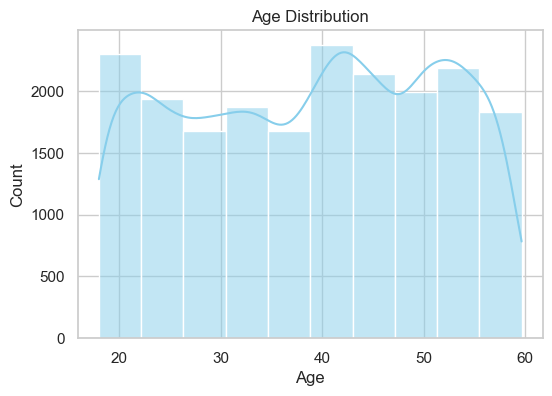

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=10, kde=True, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()
#Shows how your dataset’s ages are spread — which age group has the most users.

C:\Users\DELL\AppData\Local\Temp\ipykernel_18748\1099051768.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Recommended_Diet', data=df, palette='Set2')


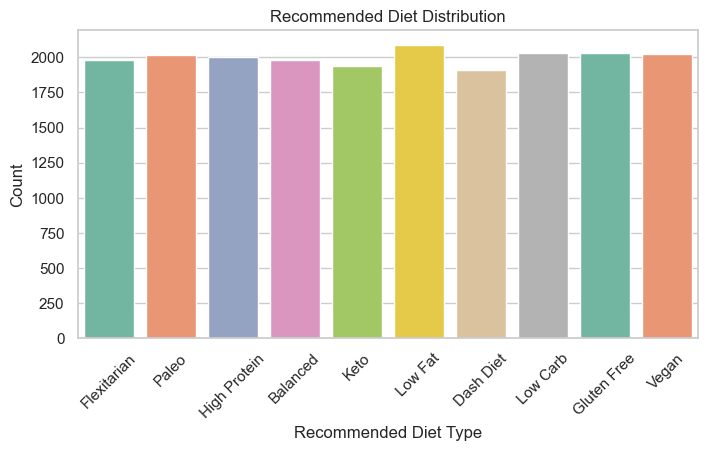

In [7]:
plt.figure(figsize=(8,4))
sns.countplot(x='Recommended_Diet', data=df, palette='Set2')
plt.title('Recommended Diet Distribution')
plt.xlabel('Recommended Diet Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()
#Displays how many users were recommended each diet type (like High Protein, Balanced, etc.).

C:\Users\DELL\AppData\Local\Temp\ipykernel_18748\2687920118.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Recommended_Yoga', data=df, palette='Set3')


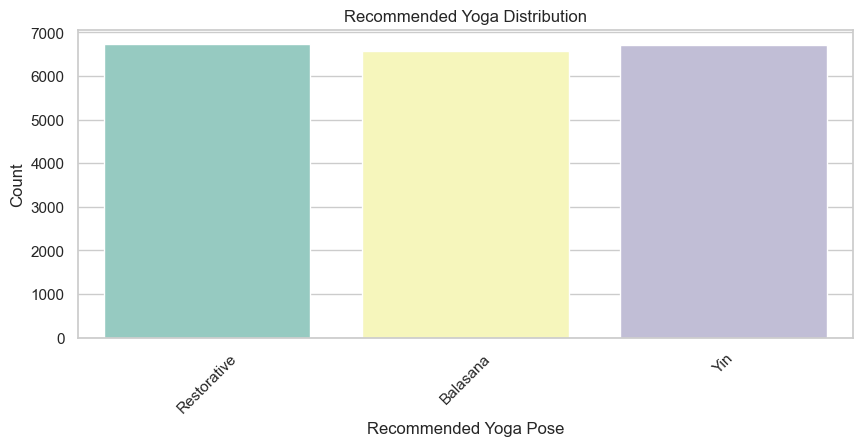

In [8]:
plt.figure(figsize=(10,4))
sns.countplot(x='Recommended_Yoga', data=df, palette='Set3')
plt.title('Recommended Yoga Distribution')
plt.xlabel('Recommended Yoga Pose')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()
#Shows which yoga poses were most commonly recommended to users.

C:\Users\DELL\AppData\Local\Temp\ipykernel_18748\3194113926.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Recommended_Yoga', y='Age', data=df, palette='Set2')


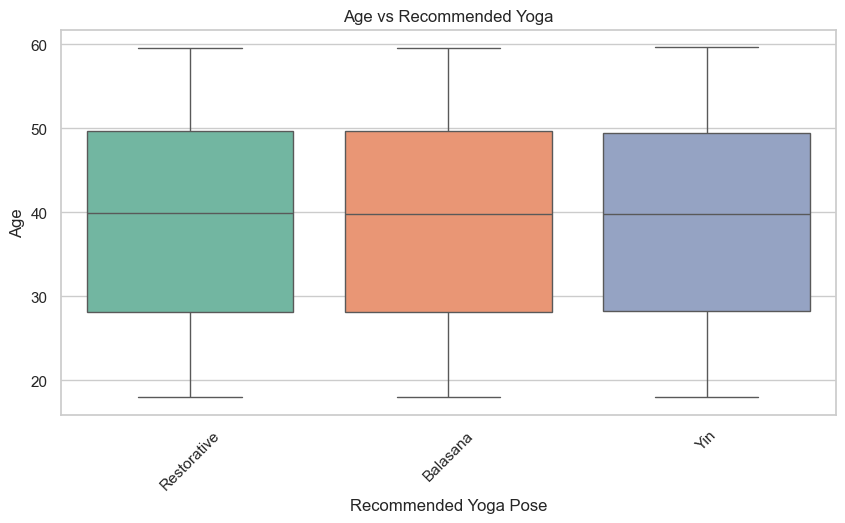

In [9]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Recommended_Yoga', y='Age', data=df, palette='Set2')
plt.title('Age vs Recommended Yoga')
plt.xlabel('Recommended Yoga Pose')
plt.ylabel('Age')
plt.xticks(rotation=45)
plt.show()
#Shows how user ages vary for different yoga poses — which poses are more common for younger/older users.

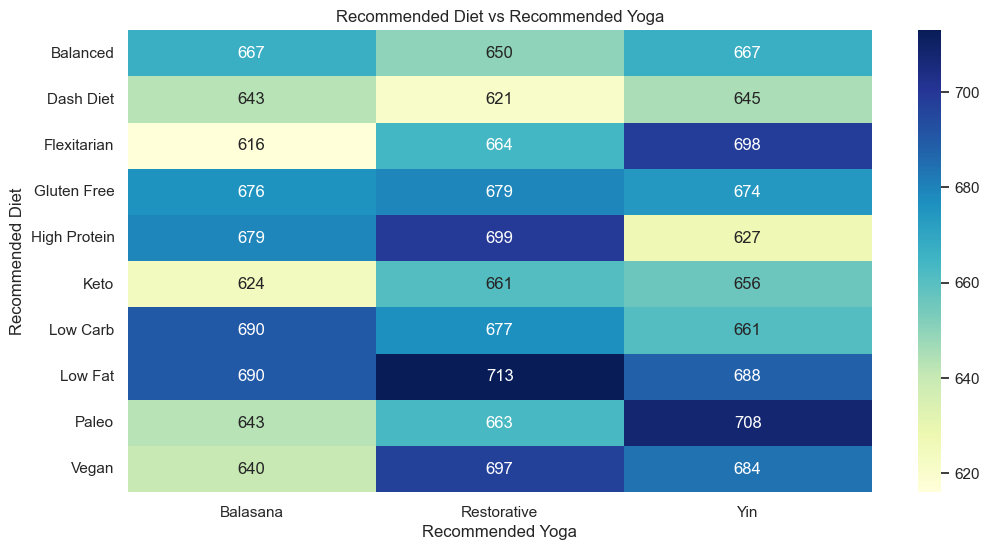

In [10]:
diet_yoga_ct = pd.crosstab(df['Recommended_Diet'], df['Recommended_Yoga'])
plt.figure(figsize=(12,6))
sns.heatmap(diet_yoga_ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Recommended Diet vs Recommended Yoga')
plt.xlabel('Recommended Yoga')
plt.ylabel('Recommended Diet')
plt.show()
#Shows how often each diet and yoga combination appears.
#Darker color → more users with that combination.

In [11]:
# ===============================
# 6️⃣ Feature Engineering (Label Encoding)
# ===============================
from sklearn.preprocessing import LabelEncoder

# Ensure we work on a copy to avoid SettingWithCopyWarning
categorical_inputs = ['Gender', 'Physical exercise', 'diet_type', 'Experience_Level', 
                      'Diet_Preference', 'Stress_Level', 'Health_Condition']

le_input = {}
for col in categorical_inputs:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_input[col] = le

# Encode outputs safely
y = y.copy()  # Make an independent copy

le_diet = LabelEncoder()
y['Recommended_Diet'] = le_diet.fit_transform(y['Recommended_Diet'].values)

le_yoga = LabelEncoder()
y['Recommended_Yoga'] = le_yoga.fit_transform(y['Recommended_Yoga'].values)


In [12]:

# ===============================
# 7️ Train/Test Split
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Multi-output Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
multi_target_rf = MultiOutputClassifier(rf)
multi_target_rf.fit(X_train, y_train)

MultiOutputClassifier(estimator=RandomForestClassifier(random_state=42))

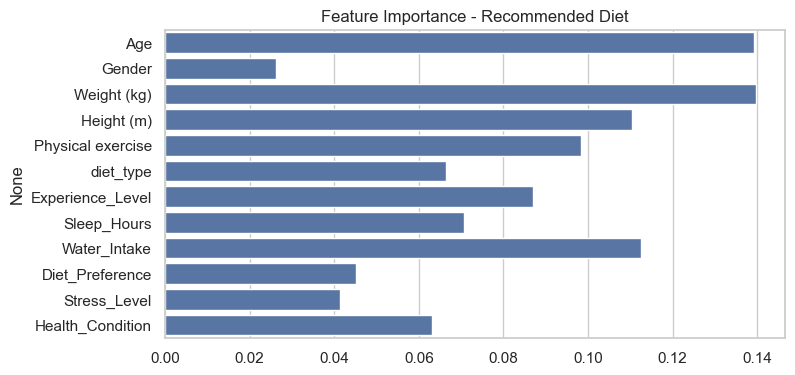

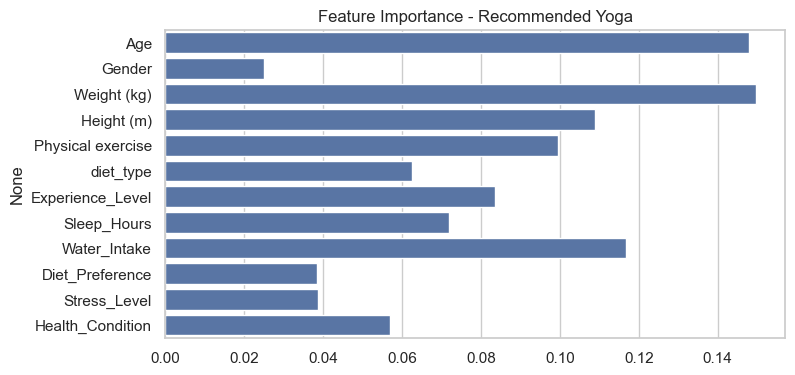

In [13]:
# 10. Feature Importance (Fixed)
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns

# Diet importance
importances_diet = multi_target_rf.estimators_[0].feature_importances_
plt.figure(figsize=(8,4))
sns.barplot(x=importances_diet, y=X.columns)
plt.title("Feature Importance - Recommended Diet")
plt.show()

# Yoga importance
importances_yoga = multi_target_rf.estimators_[1].feature_importances_
plt.figure(figsize=(8,4))
sns.barplot(x=importances_yoga, y=X.columns)
plt.title("Feature Importance - Recommended Yoga")
plt.show()


In [36]:
import os
import re

folder = r"C:\Users\DELL\Desktop\MiniProject_Ml\yoga_asanas"

for filename in os.listdir(folder):
    old_path = os.path.join(folder, filename)

    # Skip folders
    if os.path.isdir(old_path):
        continue

    name, ext = os.path.splitext(filename)

    # Clean filename: lowercase, replace spaces & symbols
    new_name = name.lower()
    new_name = re.sub(r'[\s\-]+', '_', new_name)  # spaces/hyphens → underscore
    new_name = re.sub(r'[^a-z0-9_]', '', new_name)  # remove other characters
    
    new_filename = f"{new_name}{ext.lower()}"
    new_path = os.path.join(folder, new_filename)

    # Rename only if different
    if old_path != new_path:
        os.rename(old_path, new_path)
        print(f"Renamed: {filename} → {new_filename}")


Renamed: Butterfly_Pose.jpg → butterfly_pose.jpg
Renamed: Caterpillar_Pose.jpg → caterpillar_pose.jpg
Renamed: Chaturanga_Pose.jpg → chaturanga_pose.jpg
Renamed: Child_Pose.jpg → child_pose.jpg
Renamed: Corpse_Pose.jpeg → corpse_pose.jpeg
Renamed: Downward_Dog.jpg → downward_dog.jpg
Renamed: Dragon_Pose.jpg → dragon_pose.jpg
Renamed: Hatha_Mountain_Pose.jpg → hatha_mountain_pose.jpg
Renamed: Legs_Up_Wall.jpeg → legs_up_wall.jpeg
Renamed: Sphinx_Pose.jpg → sphinx_pose.jpg
Renamed: Sun_Salutation.jpg → sun_salutation.jpg
Renamed: Supported_Bridge.jpg → supported_bridge.jpg
Renamed: Tree_Pose.jpg → tree_pose.jpg
Renamed: Triangle_Pose.jpg → triangle_pose.jpg
Renamed: Warrior.jpg → warrior.jpg
Renamed: Warrior_Ii.png → warrior_ii.png


In [ ]:
# ===============================
# 10. Model Deployment (Robust Health-Aware + CSV Logging)
# ===============================

# ---------------------------
# Helper functions
# ---------------------------
def map_height(height_input):
    """Convert user input to meters"""
    height_input = str(height_input).replace('cm', '').strip()
    h = float(height_input)
    if h > 3:   # assume cm input if > 3 meters
        h = h / 100
    return h

def map_exercise_hours(hours):
    """Map numeric exercise hours to closest category from training data"""
    exercise_classes = le_input['Physical exercise'].classes_
    closest = min(exercise_classes, key=lambda x: abs(float(x)-hours))
    return closest

def map_experience_level(level):
    """Map user-friendly experience input to numeric category"""
    mapping = {
        'Beginner': min(le_input['Experience_Level'].classes_),
        'Intermediate': sorted(le_input['Experience_Level'].classes_)[len(le_input['Experience_Level'].classes_)//2],
        'Advanced': max(le_input['Experience_Level'].classes_)
    }
    return mapping[level]

def validated_input(prompt, valid_options):
    """Prompt user until they enter a valid categorical option (case-insensitive)"""
    valid_options_clean = [str(opt).strip() for opt in valid_options]
    while True:
        value = input(prompt).strip()
        match = next((v for v in valid_options_clean if v.lower() == value.lower()), None)
        if match:
            return match
        else:
            print(f"❌ Invalid input. Please enter one of: {', '.join(valid_options_clean)}")

def numeric_input(prompt, dtype=float, min_val=None, max_val=None):
    """Prompt user until they enter a valid numeric value"""
    while True:
        try:
            value = dtype(input(prompt).strip())
            if (min_val is not None and value < min_val) or (max_val is not None and value > max_val):
                print(f"❌ Value must be between {min_val} and {max_val}.")
                continue
            return value
        except ValueError:
            print("❌ Invalid number. Please enter a valid numeric value.")

# ---------------------------
# Diet and Yoga base lists
# ---------------------------
diet_foods = {
    'Balanced': ['Eggs', 'Milk', 'Green Vegetables', 'Fruits', 'Whole Grains', 'Chicken'],
    'Keto': ['Eggs', 'Cheese', 'Avocado', 'Butter', 'Meat', 'Nuts'],
    'Low-Carb': ['Eggs', 'Chicken', 'Fish', 'Leafy Greens', 'Broccoli', 'Cauliflower'],
    'Paleo': ['Eggs', 'Lean Meat', 'Fish', 'Vegetables', 'Fruits', 'Nuts'],
    'Vegan': ['Tofu', 'Legumes', 'Green Vegetables', 'Fruits', 'Nuts', 'Seeds'],
    'Vegetarian': ['Milk', 'Eggs', 'Paneer', 'Green Vegetables', 'Fruits', 'Whole Grains'],
    'Mediterranean': ['Olive Oil', 'Fish', 'Nuts', 'Vegetables', 'Fruits', 'Whole Grains', 'Legumes']
}

yoga_asanas = {
    'Restorative': ['Child Pose', 'Legs Up the Wall', 'Corpse Pose', 'Supported Bridge'],
    'Yin': ['Butterfly Pose', 'Dragon Pose', 'Caterpillar Pose', 'Sphinx Pose'],
    'Hatha': ['Mountain Pose', 'Tree Pose', 'Warrior I', 'Downward Dog'],
    'Vinyasa': ['Sun Salutation', 'Chaturanga', 'Warrior II', 'Triangle Pose']
}

# ---------------------------
# Health-specific modifications
# ---------------------------
health_adjustments = {
    'Diabetes': {
        'prefer': ['Whole Grains', 'Leafy Greens', 'Nuts', 'Beans', 'Berries'],
        'avoid': ['Refined Sugar', 'White Bread', 'Sweetened Drinks'],
        'yoga': ['Twist Poses', 'Forward Bends']
    },
    'BP': {
        'prefer': ['Bananas', 'Oats', 'Spinach', 'Beetroot', 'Low-Sodium Foods'],
        'avoid': ['High Salt Foods', 'Pickles', 'Processed Snacks'],
        'yoga': ['Breathing Exercises', 'Restorative Poses']
    },
    'Cholesterol': {
        'prefer': ['Oats', 'Olive Oil', 'Almonds', 'Legumes', 'Fruits'],
        'avoid': ['Butter', 'Cheese', 'Red Meat'],
        'yoga': ['Sun Salutations', 'Hatha Poses']
    },
    'Other': {
        'prefer': [],
        'avoid': [],
        'yoga': []
    },
    'Unknown': {
        'prefer': [],
        'avoid': [],
        'yoga': []
    }
}


# ---------------------------
# Collect user input with field-level correction
# ---------------------------
user_data = {}

while True:
    user_data['Age'] = numeric_input("Age: ", int, 1, 120) if 'Age' not in user_data else user_data['Age']
    user_data['Gender'] = validated_input(f"Gender ({', '.join(map(str, le_input['Gender'].classes_))}): ", le_input['Gender'].classes_) if 'Gender' not in user_data else user_data['Gender']
    user_data['Weight'] = numeric_input("Weight (kg): ", float, 1, 500) if 'Weight' not in user_data else user_data['Weight']
    user_data['Height'] = map_height(numeric_input("Height (in meters e.g., 1.65 ): ", float, 0.5, 3.0)) if 'Height' not in user_data else user_data['Height']
    user_data['Physical_exercise'] = numeric_input("Physical exercise (hours per day): ", float, 0, 24) if 'Physical_exercise' not in user_data else user_data['Physical_exercise']
    user_data['Goal'] = validated_input(f"Goal / Diet type ({', '.join(map(str, le_input['diet_type'].classes_))}): ", le_input['diet_type'].classes_) if 'Goal' not in user_data else user_data['Goal']
    user_data['Experience'] = validated_input("Experience level (Beginner, Intermediate, Advanced): ", ['Beginner', 'Intermediate', 'Advanced']) if 'Experience' not in user_data else user_data['Experience']
    user_data['Sleep_Hours'] = numeric_input("Sleep hours: ", float, 0, 24) if 'Sleep_Hours' not in user_data else user_data['Sleep_Hours']
    user_data['Water_Intake'] = numeric_input("Water intake (L): ", float, 0, 10) if 'Water_Intake' not in user_data else user_data['Water_Intake']
    user_data['Diet_Preference'] = validated_input(f"Diet Preference ({', '.join(map(str, le_input['Diet_Preference'].classes_))}): ", le_input['Diet_Preference'].classes_) if 'Diet_Preference' not in user_data else user_data['Diet_Preference']
    user_data['Stress_Level'] = validated_input(f"Stress level ({', '.join(map(str, le_input['Stress_Level'].classes_))}): ", le_input['Stress_Level'].classes_) if 'Stress_Level' not in user_data else user_data['Stress_Level']
    user_data['Health_Condition'] = validated_input(f"Health condition ({', '.join(map(str, le_input['Health_Condition'].classes_))}): ", le_input['Health_Condition'].classes_) if 'Health_Condition' not in user_data else user_data['Health_Condition']

    print("\n📝 Please confirm your details:")
    for key, value in user_data.items():
        print(f"{key}: {value}")

    confirm = input("\nIs all information correct? (Y/N): ").strip().lower()
    if confirm == 'y':
        break
    else:
        print("\nEnter the field names you want to correct (comma-separated), e.g., Weight, Height, Stress_Level")
        fields_to_correct = input("Fields to correct: ").strip().split(',')
        fields_to_correct = [f.strip().replace(' ', '_').title() for f in fields_to_correct]
        for field in fields_to_correct:
            if field in user_data:
                del user_data[field]
        print("\n✅ Let's update the selected fields.\n")

# ---------------------------
# Map and encode inputs
# ---------------------------
exercise_cat = map_exercise_hours(user_data['Physical_exercise'])
experience_cat = map_experience_level(user_data['Experience'])

new_user = pd.DataFrame({
    'Age': [user_data['Age']],
    'Gender': [le_input['Gender'].transform([user_data['Gender']])[0]],
    'Weight (kg)': [user_data['Weight']],
    'Height (m)': [user_data['Height']],
    'Physical exercise': [le_input['Physical exercise'].transform([exercise_cat])[0]],
    'diet_type': [le_input['diet_type'].transform([user_data['Goal']])[0]],
    'Experience_Level': [le_input['Experience_Level'].transform([experience_cat])[0]],
    'Sleep_Hours': [user_data['Sleep_Hours']],
    'Water_Intake': [user_data['Water_Intake']],
    'Diet_Preference': [le_input['Diet_Preference'].transform([user_data['Diet_Preference']])[0]],
    'Stress_Level': [le_input['Stress_Level'].transform([user_data['Stress_Level']])[0]],
    'Health_Condition': [le_input['Health_Condition'].transform([user_data['Health_Condition']])[0]]
})

# ---------------------------
# Predict Diet + Yoga
# ---------------------------
pred = multi_target_rf.predict(new_user)
pred_diet = le_diet.inverse_transform([pred[0][0]])[0]
pred_yoga = le_yoga.inverse_transform([pred[0][1]])[0]

# ---------------------------
# Health-aware adjustments
# ---------------------------
health = user_data['Health_Condition']
avoid_foods = health_adjustments[health]['avoid']
additional_yoga = health_adjustments[health]['yoga']

recommended_foods = [f for f in diet_foods.get(pred_diet, []) if f not in avoid_foods]
recommended_asanas = yoga_asanas.get(pred_yoga, []) + additional_yoga

# ---------------------------
# Final Recommendation Output
# ---------------------------
print("\n==============================================")
print("✅ Recommended for you:")
print("==============================================")

print(f" - Diet Type: {pred_diet}")

# Prefer foods (diet + health-based)
print("   Foods to Prefer:", ", ".join(recommended_foods) if recommended_foods else "No specific foods")

# Avoid foods
if avoid_foods:
    print(f"   ⚠ Foods to Avoid: {', '.join(avoid_foods)}")
else:
    print("   ⚠ Foods to Avoid: None")

print(f" - Yoga Type: {pred_yoga}")

# Suggested asanas (yoga-type + health-based)
print("   Suggested Asanas:", ", ".join(recommended_asanas) if recommended_asanas else "No specific asanas")

print("==============================================")

# ---------------------------
# INSERT ASANA IMAGES HERE
# ---------------------------
from IPython.display import Image, display
import os

def show_asana_image_or_link(asana_name, image_folder):
    # Convert asana to filename style
    clean_name = asana_name.lower().replace(" ", "_")
    
    # Accepted extensions
    extensions = [".jpg", ".jpeg", ".png", ".webp"]

    # Search for a file
    found_file = None
    for ext in extensions:
        file_path = os.path.join(image_folder, clean_name + ext)
        if os.path.exists(file_path):
            found_file = file_path
            break

    if found_file:
        print(f"\n🧘 Showing image for: {asana_name}")
        display(Image(filename=found_file, width=350))  # 👉 SHOW IMAGE
    else:
        print(f"\n⚠ No image found for: {asana_name}")
        google_link = f"https://www.google.com/search?q={asana_name.replace(' ', '+')}+yoga"
        print(f"🔗 Google Link: {google_link}")

print("\n🧘 Showing images for your suggested asanas…")

# Loop through your asanas and show image or google link

for asana in recommended_asanas:
    show_asana_image_or_link(asana, image_base_path)

# ---------------------------
# Save to CSV (Corrected)
# ---------------------------
import os

# Build a dictionary from actual user inputs + model predictions
new_recommendation = {
    'Age': user_data.get('Age'),
    'Gender': user_data.get('Gender'),
    'Weight (kg)': user_data.get('Weight'),
    'Height (m)': user_data.get('Height'),
    'Physical exercise': user_data.get('Physical_exercise'),
    'diet_type': user_data.get('Goal'),
    'Experience_Level': user_data.get('Experience'),
    'Sleep_Hours': user_data.get('Sleep_Hours'),
    'Water_Intake': user_data.get('Water_Intake'),
    'Diet_Preference': user_data.get('Diet_Preference'),
    'Stress_Level': user_data.get('Stress_Level'),
    'Health_Condition': user_data.get('Health_Condition'),
    'Recommended_Diet': pred_diet,    # from model
    'Recommended_Yoga': pred_yoga     # from model
}

df_new = pd.DataFrame([new_recommendation])

csv_file = 'diet_yoga_recommendations.csv'
write_header = not os.path.exists(csv_file)

df_new.to_csv(csv_file, mode='a', header=write_header, index=False)

print(f"\n✅ Recommendation saved to {csv_file}")
